In [29]:
# устанвока библиотек
!pip install requests beautifulsoup4 pandas nltk pymorphy3 wordcloud scikit-learn
# для чтения
import os
os.getcwd()
# для красивого вида табличек
from IPython.display import display
# для парсинга и табличек
import requests
from bs4 import BeautifulSoup
import time
import re
import pandas as pd
# для очистки
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk import download
download('punkt_tab')
# стоп-слова
download('stopwords')
from nltk.corpus import stopwords
#для частеречной разметки
!pip install pymorphy3
import pymorphy3
morph = pymorphy3.MorphAnalyzer()
# для подсчета частот 
from collections import Counter
# для визуализации 
#облака
!pip install wordcloud
from wordcloud import WordCloud
#графики
!pip install matplotlib 
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
# для heatmap
!pip install seaborn
import seaborn as sns

# векторизатор
from sklearn.feature_extraction.text import TfidfVectorizer

#для коллокаций
from nltk.collocations import * #импортируем сразу все
from nltk.metrics import TrigramAssocMeasures


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Как работать с файлами: 
1. Создайте папку `Zodiac` в той же директории, куда установили этот ноутбук
3. Скачайте csv-данные по ссылке: https://drive.google.com/drive/folders/1RwZZL32A5W-TZ4M0UZ5XhV3OiWRv5zKS?usp=sharing
4. Положите все CSV файлы из архива в папку `Zodiac/`
5. Запускайте ячейки по порядку

In [30]:
# Cписок ссылок для парсинга, для некоторых знаков понабодилось несколько ссылок, чтобы сравнять по кол-ву комментариев с остальными ветками
# После защиты были докачены ссылки и датасет расширен
project_folder = "Zodiac" # создали папку для хранения
if not os.path.exists(project_folder):
    os.makedirs(project_folder)
    print(f"Создана папка: {project_folder}")


# функция для парсинга треда
def parse_thread(base_id, start_page, end_page):
    base_url = f"https://www.woman.ru/horoscope/medley10/thread/{base_id}"
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
    session = requests.Session()
    session.headers.update(headers)
    page_data = [] # список, куда запишутся комментарии
    for page_num in range(start_page, end_page + 1):
        try:
            # Формируем URL для текущей страницы
            if page_num == 1:
                # Для первой страницы URL может быть без номера или с номером 1
                url = f"{base_url}/"
            else:
                url = f"{base_url}/{page_num}/"
            response = session.get(url, timeout=10)
            soup = BeautifulSoup(response.text, 'html.parser')
            for comment in soup.find_all("div", {'class': 'card__comment'}):
                metadata = comment.find_previous('div', {'class': 'user__metadata'}) # ищем объект tag
                user_id = None
                if metadata:
                    # Внутри metadata ищем span с классом user__metadata_id
                    id_span = metadata.find('span', {'class': 'user__metadata_id'})
                    if id_span:
                        user_id = id_span.get('data-id') 
                text = comment.text
                page_data.append({
                    "user_id": user_id,
                    "text": text
                })
            time.sleep(1.5)
        except requests.exceptions.RequestException as e:
            print(f"  ✗ Ошибка при запросе страницы {page_num}: {e}")
    return page_data
#список тредов
threads_to_parse = [
    {'base_id': 4719457, 'zodiac_sign': 'capricorn', 'start_page': 1, 'end_page': 25},
    {'base_id': 4044883, 'zodiac_sign': 'capricorn', 'start_page': 1, 'end_page': 118},
    {'base_id': 3851215, 'zodiac_sign': 'aquarius', 'start_page': 1, 'end_page': 220},
    {'base_id': 3729426, 'zodiac_sign': 'pisces', 'start_page': 1, 'end_page': 220},
    {'base_id': 4375020, 'zodiac_sign': 'aries', 'start_page': 1, 'end_page': 3},
    {'base_id': 3786010, 'zodiac_sign': 'aries', 'start_page': 1, 'end_page': 72}, # добавили
    {'base_id': 4041962, 'zodiac_sign': 'aries', 'start_page': 1, 'end_page': 2},
    {'base_id': 4330697, 'zodiac_sign': 'aries', 'start_page': 1, 'end_page': 2},
    {'base_id': 4604848, 'zodiac_sign': 'aries', 'start_page': 1, 'end_page': 3},
    {'base_id': 4054473, 'zodiac_sign': 'aries', 'start_page': 1, 'end_page': 2},
    {'base_id': 4117478, 'zodiac_sign': 'taurus', 'start_page': 1, 'end_page': 200},
    {'base_id': 3951237, 'zodiac_sign': 'gemini', 'start_page': 1, 'end_page': 3},
    {'base_id': 3873999, 'zodiac_sign': 'gemini', 'start_page': 1, 'end_page': 8},
    {'base_id': 4043991, 'zodiac_sign': 'gemini', 'start_page': 1, 'end_page': 4},
    {'base_id': 3854256, 'zodiac_sign': 'gemini', 'start_page': 1, 'end_page': 9}, # добавили
    {'base_id': 3856937, 'zodiac_sign': 'gemini', 'start_page': 1, 'end_page': 43},
    {'base_id': 3959556, 'zodiac_sign': 'cancer', 'start_page': 1, 'end_page': 250}, #добавили страниц
    {'base_id': 4208548, 'zodiac_sign': 'leo', 'start_page': 1, 'end_page': 4},
    {'base_id': 3816003, 'zodiac_sign': 'leo', 'start_page': 1, 'end_page': 250}, # добавили
    {'base_id': 4321654, 'zodiac_sign': 'leo', 'start_page': 1, 'end_page': 3},
    {'base_id': 4714594, 'zodiac_sign': 'leo', 'start_page': 1, 'end_page': 2},
    {'base_id': 6060976, 'zodiac_sign': 'leo', 'start_page': 1, 'end_page': 5},
    {'base_id': 4050804, 'zodiac_sign': 'leo', 'start_page': 1, 'end_page': 3},
    {'base_id': 5040330, 'zodiac_sign': 'leo', 'start_page': 1, 'end_page': 1},
    {'base_id': 4582214, 'zodiac_sign': 'leo', 'start_page': 1, 'end_page': 3},
    {'base_id': 4380646, 'zodiac_sign': 'leo', 'start_page': 1, 'end_page': 2},
    {'base_id': 3935661, 'zodiac_sign': 'leo', 'start_page': 1, 'end_page': 2},
    {'base_id': 4015547, 'zodiac_sign': 'leo', 'start_page': 1, 'end_page': 2},
    {'base_id': 4321654, 'zodiac_sign': 'leo', 'start_page': 1, 'end_page': 3},
    {'base_id': 3845342, 'zodiac_sign': 'leo', 'start_page': 1, 'end_page': 9}, # добавили
    {'base_id': 38015, 'zodiac_sign': 'virgo', 'start_page': 1, 'end_page': 250}, #добавили страниц
    {'base_id': 4732212, 'zodiac_sign': 'libra', 'start_page': 1, 'end_page': 4},
    {'base_id': 4071263, 'zodiac_sign': 'libra', 'start_page': 1, 'end_page': 2},
    {'base_id': 4136435, 'zodiac_sign': 'libra', 'start_page': 1, 'end_page': 2},
    {'base_id': 4323525, 'zodiac_sign': 'libra', 'start_page': 1, 'end_page': 3},
    {'base_id': 4029937, 'zodiac_sign': 'libra', 'start_page': 1, 'end_page': 7}, # добавили
    {'base_id': 4876569, 'zodiac_sign': 'libra', 'start_page': 1, 'end_page': 17}, # добавили
    {'base_id': 3859394, 'zodiac_sign': 'libra', 'start_page': 1, 'end_page': 200}, # добавили, но немного другая тематика
    {'base_id': 4322889, 'zodiac_sign': 'scorpio', 'start_page': 1, 'end_page': 3},
    {'base_id': 5361861, 'zodiac_sign': 'scorpio', 'start_page': 1, 'end_page': 3},
    {'base_id': 3989371, 'zodiac_sign': 'scorpio', 'start_page': 1, 'end_page': 4},
    {'base_id': 3808525, 'zodiac_sign': 'scorpio', 'start_page': 1, 'end_page': 250}, # добавили
    {'base_id': 4958867, 'zodiac_sign': 'sagitarius', 'start_page': 1, 'end_page': 41},
    {'base_id': 3935087, 'zodiac_sign': 'sagitarius', 'start_page': 1, 'end_page': 100}, # добавили, но немного другая "тематика"
    {'base_id': 3908282, 'zodiac_sign': 'sagitarius', 'start_page': 1, 'end_page': 15}, # добавили
    {'base_id': 3779156, 'zodiac_sign': 'sagitarius', 'start_page': 1, 'end_page': 76}, # добавили
    {'base_id': 4330260, 'zodiac_sign': 'sagitarius', 'start_page': 1, 'end_page': 3}, # добавили
    {'base_id': 4034258, 'zodiac_sign': 'sagitarius', 'start_page': 1, 'end_page': 4}  # добавили
]

# цикл, который проходится по нашим тредам
for thread in threads_to_parse:
    
    filename = f"{thread['zodiac_sign']}_thread_{thread['base_id']}.csv"
    filepath = os.path.join(project_folder, filename)
    if os.path.exists(filepath):
        continue
    result = parse_thread(
        base_id=thread['base_id'],
        start_page=thread['start_page'],
        end_page=thread['end_page']
    )
    df = pd.DataFrame(result)

    df.to_csv(filepath, index=False, encoding='utf-8-sig', quoting=1)

print(os.listdir('Zodiac')) #посмотрели, что все записалось

['aquarius_combined.csv', 'aquarius_processed.csv', 'aquarius_thread_3851215.csv', 'aries_combined.csv', 'aries_processed.csv', 'aries_thread_3786010.csv', 'aries_thread_4041962.csv', 'aries_thread_4054473.csv', 'aries_thread_4330697.csv', 'aries_thread_4375020.csv', 'aries_thread_4604848.csv', 'cancer_combined.csv', 'cancer_processed.csv', 'cancer_thread_3959556.csv', 'capricorn_combined.csv', 'capricorn_processed.csv', 'capricorn_thread_4044883.csv', 'capricorn_thread_4719457.csv', 'gemini_combined.csv', 'gemini_processed.csv', 'gemini_thread_3854256.csv', 'gemini_thread_3856937.csv', 'gemini_thread_3873999.csv', 'gemini_thread_3951237.csv', 'gemini_thread_4043991.csv', 'leo_combined.csv', 'leo_processed.csv', 'leo_thread_3816003.csv', 'leo_thread_3845342.csv', 'leo_thread_3935661.csv', 'leo_thread_4015547.csv', 'leo_thread_4050804.csv', 'leo_thread_4208548.csv', 'leo_thread_4321654.csv', 'leo_thread_4380646.csv', 'leo_thread_4582214.csv', 'leo_thread_4714594.csv', 'leo_thread_504033

In [31]:
# объединим датасеты (те, где было несколько тредов)
# словарь для хранения зодиак: датафреймы 
zodiac_data = {}


# проходим по всем знакам зодиака из списка тредов
for thread in threads_to_parse:
    zodiac = thread['zodiac_sign']
    filename = f"{zodiac}_thread_{thread['base_id']}.csv"
    filepath = os.path.join(project_folder, filename)
    
    # проверяем, существует ли файл
    if os.path.exists(filepath):
        # Читаем CSV файл
        df = pd.read_csv(filepath)
        if zodiac not in zodiac_data:
            zodiac_data[zodiac] = [df]
        else:
            zodiac_data[zodiac].append(df)

for zodiac, dataframes in zodiac_data.items():
    if isinstance(dataframes, list): # если это лист из df (для нескольких веток по знаку)
        # Объединяем все датафреймы для этого знака
        combined_df = pd.concat(dataframes, ignore_index=True) # С ignore_index=True получаем единую последовательность индексов при объединении датафреймов
    else:
        combined_df = dataframes # если была одна ветка для знака, то она и конкатенировать нечего
        # Сохраняем объединенный файл
    output_filename = f"{zodiac}_combined.csv"
    output_filepath = os.path.join(project_folder, output_filename)
    combined_df.to_csv(output_filepath, index=False, encoding='utf-8-sig', quoting=1)
    zodiac_data[zodiac] = combined_df

#выведем количество строк для каждого дф, что у нас получились. видим, что где-то перевес
for zodiac, df in zodiac_data.items():
        print(f"{zodiac}: {len(df)} строк")
display(zodiac_data['libra'].head(10)) # видим, что id топик-стартера записался как NaN, т.к. текст топик-стартера нам вообще не нужен можно удалить из дф

capricorn: 7405 строк
aquarius: 10400 строк
pisces: 10400 строк
aries: 4236 строк
taurus: 10400 строк
gemini: 3331 строк
cancer: 10400 строк
leo: 14737 строк
virgo: 10400 строк
libra: 7309 строк
scorpio: 10697 строк
sagitarius: 4104 строк


,user_id,text
0,NaN,НУЖЕН СОВЕТ!!Познакомилась на сайте знакомств...
1,1.839144e+09,Весы-лучший знак!
2,2.392252e+09,Ооо эти ..... Весы!!! Прожила 5 лет и не к че...
3,4.066915e+09,"Очень странные ребята,боятся скандалов,но все..."
4,8.240507e+08,"Весам нужна сильная женщина, Овен, Стрелец, К..."
5,3.785504e+09,Да не за серьезными отношениями мужик сидит н...
6,3.248653e+09,Посоветуйте мне) нужна ли инициатива со сторо...
7,3.785504e+09,"Если молчит, то не очень то вы ему нужны. Есл..."
8,3.248653e+09,Скорее всего вы правы. Хотя признавать этого ...
9,3.007326e+09,У меня муж весы. Это просто капец. Восемь лет...


## Посчитали, сколько осталось комментариев без NaN

In [32]:
zodiac_data_clean = {} # сюда положим наши "зодиак:дф" без NaN user'ов
for zodiac, df in zodiac_data.items():
    df_clean = df.dropna(subset=['user_id']).reset_index(drop=True)
    zodiac_data_clean[zodiac] = df_clean
    print(f"Было строк: {len(zodiac_data[zodiac])}")
    print(f"Стало строк: {len(zodiac_data_clean[zodiac])}")
display(zodiac_data_clean['libra'].head(60))

Было строк: 7405
Стало строк: 7262
Было строк: 10400
Стало строк: 10200
Было строк: 10400
Стало строк: 10200
Было строк: 4236
Стало строк: 4153
Было строк: 10400
Стало строк: 10200
Было строк: 3331
Стало строк: 3264
Было строк: 10400
Стало строк: 10200
Было строк: 14737
Стало строк: 14448
Было строк: 10400
Стало строк: 10200
Было строк: 7309
Стало строк: 7165
Было строк: 10697
Стало строк: 10489
Было строк: 4104
Стало строк: 4024


,user_id,text
0,1.839144e+09,Весы-лучший знак!
1,2.392252e+09,Ооо эти ..... Весы!!! Прожила 5 лет и не к че...
2,4.066915e+09,"Очень странные ребята,боятся скандалов,но все..."
3,8.240507e+08,"Весам нужна сильная женщина, Овен, Стрелец, К..."
4,3.785504e+09,Да не за серьезными отношениями мужик сидит н...
5,3.248653e+09,Посоветуйте мне) нужна ли инициатива со сторо...
6,3.785504e+09,"Если молчит, то не очень то вы ему нужны. Есл..."
7,3.248653e+09,Скорее всего вы правы. Хотя признавать этого ...
8,3.007326e+09,У меня муж весы. Это просто капец. Восемь лет...
9,2.289586e+09,Присоединяюсь!Любовник бывший - Весы. Волевых...


In [33]:
# Надо переходить к очистке
stop_words = stopwords.words('russian')
stop_words = set(stop_words)
stop_words.discard('не') # для дальнейших задач удалим "не" из списка стоп-слов

#Шаблоны для удаления спама
additional_patterns = [r'в данном разделе в темах[\s\S]*',
                       r'когда моего мужа увела его бывшая жена[\s\S]*', 
                       r'возвращала своего парня у ведуньи[\s\S]*',
                       r'ваш текст\n',
                       r'\[quote=.*\n',
                       r'\[.+\[/', # для сломанного цитирования вида: [ =""Лена"" _ ="" ""]это Вы тему создали?[/
                       r'\d+', 
                       r'[-–—]', #весы-хороший знак
                       r'^[.,!?\-\[\]\(\)\{\}\s]+$',
                       r'https?://\S+', 
                       r'www\.\S+',
                       r'[a-zA-Z]+', 
                       r'\.{2,}',  # заменяем многоточия на пробел
                       r'…']        # заменяем горизонтальное многоточие

def clean_tokens(text):
    if not isinstance(text, str) or not text.strip(): # проверка для 
        return []
    text = text.lower()
    for pattern in additional_patterns:
        text = re.sub(pattern, ' ', text)
    text_list_nltk = word_tokenize(text)
    text_without_punkt = [word for word in text_list_nltk if word.isalpha()]
    tokens = [re.sub(r'\W+', '', token) for token in text_without_punkt if len(token) > 2 or token == 'не']
    text_clean = [word for word in tokens if word not in stop_words]
    return text_clean




## Применяем очистку и смотрим, сколько мусора ушло

In [34]:
zodiac_data_processed = {} # это будет новый словарь с обработанными датасетами
for zodiac, df in zodiac_data_clean.items(): # работает с новым дф
    before = len(df)
    df['text_cleaned'] = df['text'].apply(clean_tokens)
    df_cleaned = df[df['text_cleaned'].apply(len) > 0].reset_index(drop=True) # удалим все пустые строки и переиндексируем список
    zodiac_data_processed[zodiac] = df_cleaned
    print(f'{zodiac}, размер датасета до: {before}, после {len(df_cleaned)}')

display(zodiac_data_processed['libra'].head(30))

capricorn, размер датасета до: 7262, после 6973
aquarius, размер датасета до: 10200, после 9828
pisces, размер датасета до: 10200, после 9906
aries, размер датасета до: 4153, после 3949
taurus, размер датасета до: 10200, после 9830
gemini, размер датасета до: 3264, после 3108
cancer, размер датасета до: 10200, после 9576
leo, размер датасета до: 14448, после 13957
virgo, размер датасета до: 10200, после 9898
libra, размер датасета до: 7165, после 6911
scorpio, размер датасета до: 10489, после 10121
sagitarius, размер датасета до: 4024, после 3893


,user_id,text,text_cleaned
0,1.839144e+09,Весы-лучший знак!,"[весы, лучший, знак]"
1,2.392252e+09,Ооо эти ..... Весы!!! Прожила 5 лет и не к че...,"[ооо, весы, прожила, лет, не, чему, не, пришли..."
2,4.066915e+09,"Очень странные ребята,боятся скандалов,но все...","[очень, странные, ребята, боятся, скандалов, п..."
3,8.240507e+08,"Весам нужна сильная женщина, Овен, Стрелец, К...","[весам, нужна, сильная, женщина, овен, стрелец..."
4,3.785504e+09,Да не за серьезными отношениями мужик сидит н...,"[не, серьезными, отношениями, мужик, сидит, са..."
5,3.248653e+09,Посоветуйте мне) нужна ли инициатива со сторо...,"[посоветуйте, нужна, инициатива, стороны, деву..."
6,3.785504e+09,"Если молчит, то не очень то вы ему нужны. Есл...","[молчит, не, очень, нужны, мужчине, нужна, жен..."
7,3.248653e+09,Скорее всего вы правы. Хотя признавать этого ...,"[скорее, правы, хотя, признавать, не, хочется,..."
8,3.007326e+09,У меня муж весы. Это просто капец. Восемь лет...,"[муж, весы, это, просто, капец, восемь, лет, н..."
9,2.289586e+09,Присоединяюсь!Любовник бывший - Весы. Волевых...,"[присоединяюсь, любовник, бывший, весы, волевы..."


In [35]:
def merge_negations(tokens): # функция для склеивания не с нужными чр предоставлена deepseek
    result = []
    i = 0
    while i < len(tokens):
        if tokens[i] == 'не' and i + 1 < len(tokens):
            next_token = tokens[i + 1]
            pos = morph.parse(next_token)[0].tag.POS
            if pos in ('ADJF', 'ADJS', 'ADVB'):  # прилагательное или наречие
                result.append('не' + next_token)
                i += 2
            else:
                result.append(tokens[i])  # оставляем "не" отдельно
                i += 1
        else:
            result.append(tokens[i])
            i += 1
    return result


## Частеречный парсер

In [37]:
# частеречный парсер

def parse_info(tokens):
    if not tokens:
        return {'lemmas': [],
                'pos': [],
                'case': [],
                'number': [],
                'gender': []
                }
# подготавливаем списки для разных типов информации
    lemmas_result = []
    parse_result = []
    pos_result = []
    case_result = []
    number_result = []
    gender_result = []

    for token in tokens:
        parse = morph.parse(token)[0] # берем первый (самый вероятный) вариант
    # Сохраняем информацию
        lemmas_result.append(parse.normal_form)
        parse_result.append(str(parse))  # полный разбор как строка
        
        # Извлекаем грамматические характеристики
        pos_result.append(parse.tag.POS)  # часть речи
        case_result.append(parse.tag.case)  # падеж
        number_result.append(parse.tag.number)  # число
        gender_result.append(parse.tag.gender)  # род
    
    return {
        'lemmas': lemmas_result,
        'parse': parse_result,
        'pos': pos_result,
        'case': case_result,
        'number': number_result,
        'gender': gender_result
    }

for zodiac, df in zodiac_data_processed.items():
    df['text_cleaned'] = df['text_cleaned'].apply(merge_negations)  # сначала склеиваем
    results = df['text_cleaned'].apply(parse_info)
    df['lemmas'] = results.apply(lambda x: x['lemmas'])
    df['pos'] = results.apply(lambda x: x['pos'])
    df['case'] = results.apply(lambda x: x['case'])
    df['number'] = results.apply(lambda x: x['number'])
    df['gender'] = results.apply(lambda x: x['gender'])
    zodiac_data_processed[zodiac] = df
# сохраняем
    filepath = os.path.join(project_folder, f"{zodiac}_processed.csv")
    if not os.path.exists(filepath):
        df.to_csv(filepath, index=False, encoding='utf-8-sig', quoting=1)
    
display(zodiac_data_processed['libra'].head(30))

,user_id,text,text_cleaned,lemmas,pos,case,number,gender
0,1.839144e+09,Весы-лучший знак!,"[весы, лучший, знак]","[весы, хороший, знак]","[NOUN, ADJF, NOUN]","[nomn, nomn, nomn]","[plur, sing, sing]","[None, masc, masc]"
1,2.392252e+09,Ооо эти ..... Весы!!! Прожила 5 лет и не к че...,"[ооо, весы, прожила, лет, не, чему, не, пришли...","[ооо, весы, прожить, год, не, что, не, прислат...","[NOUN, NOUN, VERB, NOUN, PRCL, NPRO, PRCL, VER...","[nomn, nomn, None, gent, None, datv, None, Non...","[sing, plur, sing, plur, None, sing, None, sin...","[neut, None, femn, masc, None, neut, None, Non..."
2,4.066915e+09,"Очень странные ребята,боятся скандалов,но все...","[очень, странные, ребята, боятся, скандалов, п...","[очень, странный, ребята, бояться, скандал, пр...","[ADVB, ADJF, NOUN, VERB, NOUN, VERB, VERB, NOU...","[None, nomn, nomn, None, gent, None, None, gen...","[None, plur, plur, plur, plur, plur, plur, plu...","[None, None, None, None, masc, None, None, neu..."
3,8.240507e+08,"Весам нужна сильная женщина, Овен, Стрелец, К...","[весам, нужна, сильная, женщина, овен, стрелец...","[весы, нужный, сильный, женщина, овен, стрелец...","[NOUN, ADJS, ADJF, NOUN, NOUN, NOUN, NOUN, VER...","[datv, None, nomn, nomn, nomn, nomn, nomn, Non...","[plur, sing, sing, sing, sing, sing, sing, plu...","[None, femn, femn, femn, masc, masc, masc, Non..."
4,3.785504e+09,Да не за серьезными отношениями мужик сидит н...,"[несерьезными, отношениями, мужик, сидит, сайт...","[несерьёзный, отношение, мужик, сидеть, сайт, ...","[ADJF, NOUN, NOUN, VERB, NOUN, NOUN, ADVB, VER...","[ablt, ablt, nomn, None, loct, gent, None, Non...","[plur, plur, sing, sing, sing, plur, None, plu...","[None, neut, masc, None, masc, neut, None, Non..."
5,3.248653e+09,Посоветуйте мне) нужна ли инициатива со сторо...,"[посоветуйте, нужна, инициатива, стороны, деву...","[посоветовать, нужный, инициатива, сторона, де...","[VERB, ADJS, NOUN, NOUN, NOUN, ADJF, NOUN, NOU...","[None, None, nomn, gent, nomn, loct, loct, gen...","[plur, sing, sing, sing, plur, sing, sing, plu...","[None, femn, femn, femn, femn, femn, femn, neu..."
6,3.785504e+09,"Если молчит, то не очень то вы ему нужны. Есл...","[молчит, неочень, нужны, мужчине, нужна, женщи...","[молчать, неочень, нужный, мужчина, нужный, же...","[VERB, NOUN, ADJS, NOUN, ADJS, NOUN, VERB, NOU...","[None, nomn, None, datv, None, nomn, None, acc...","[sing, sing, plur, sing, sing, sing, sing, sin...","[None, masc, None, masc, femn, femn, None, neu..."
7,3.248653e+09,Скорее всего вы правы. Хотя признавать этого ...,"[скорее, правы, хотя, признавать, не, хочется,...","[скорее, правый, хотя, признавать, не, хотетьс...","[CONJ, ADJS, CONJ, INFN, PRCL, VERB, CONJ, VER...","[None, None, None, None, None, None, None, Non...","[None, plur, None, None, None, sing, None, sin...","[None, None, None, None, None, None, None, mas..."
8,3.007326e+09,У меня муж весы. Это просто капец. Восемь лет...,"[муж, весы, это, просто, капец, восемь, лет, н...","[муж, весы, это, просто, капец, восемь, год, н...","[NOUN, NOUN, PRCL, PRCL, NOUN, NUMR, NOUN, ADV...","[nomn, nomn, None, None, nomn, accs, gent, Non...","[sing, plur, None, None, sing, None, plur, Non...","[masc, None, None, None, masc, None, masc, Non..."
9,2.289586e+09,Присоединяюсь!Любовник бывший - Весы. Волевых...,"[присоединяюсь, любовник, бывший, весы, волевы...","[присоединяться, любовник, бывший, весы, волев...","[VERB, NOUN, ADJF, NOUN, ADJF, NOUN, PRCL, INF...","[None, nomn, nomn, nomn, gent, gent, None, Non...","[sing, sing, sing, plur, plur, plur, None, Non...","[None, masc, masc, None, None, neut, None, Non..."


## Посчитаем относительные частоты прилагательных мужского рода для каждого знака (частота прил. муж. р/ число всех прил. муж. рода этого знака)

In [38]:


adjective_stop_words = ['каждый', 'бывший', 'какой', 'такой', 'который', 'этот', 'тот', 'весь', 'сам', 'один',
    'свой', 'мой', 'твой', 'ваш', 'наш', 'ихний', 'некий', 'новый', 'близкий', 'личный', 'всякий', 'определённый', 'знакомый', 'его', 'её', 'первый', 'второй', 'третий', 'последний', 'очередной','данный', 'немой', 'вообщий', 'вобщий', 'должный', 'кой',
    'нужный', 'любой', 'другой', 'остальной', 'реальный', 'следующий','готовый', 'занятый', 'полный', 'целый', 'самый', 'иной', 'прочий', 'определенный', 'разный', 'большой', 'внутренний', 'высокий',	'детский',	'довольный',
    'женский', 'жизненный',' лишний', 'молодой','подобный', 'предыдущий', 'прошлый','русский', 'старый', 'лишний', 'подходящий', 'огромный', 'свободный', 'больший', 'мужской',
    'английский', 'черный','чёрный','таковой', 'чей', 'конечный', 'романтический', 'вчерашний', 'мобильный','здравый', 'летний', 'интимный', 'моральный', 'положительный', 'чистый',
    'материальный', 'родный', 'собственный', 'честной', 'адекватный', 'конкретный','крайний', 'незнакомый', 'трезвый', 'будущий', 'удачный', 'сегодняшний',
    'истинный', 'живой', 'понятный', 'обратный', 'особый', 'печальный', 'ненужный', 'непервый', 'анальный', 
    'ведущий',	'давный',	'длинный',	'зимний', 'зодиакальный',	'левый', 'нелюбимый', 'сирый',	'несогласный',	'неспособный', 'сплошной', 'уважаемый',
    'бедненький',	'бурный',	'векторный', 'дурацкий','неважный', 'проч',	'серый', 'солнечный',
    'божий', 'белый','водолейский','вумный','голодный','немаленький','подчинённый','ровный', 'тянутый', 'апрельский', 'голубой', 'младший', 'рыбий',
    'французский', 'мелкий', 'сотовый', 'восновный',
    'необщий', 'ценный', 'стреловый', 'дешевый', 'отрицательный', 'нескромный', 
    'львиный', 'неподходящий', 'дешёвый', 'офигенный', 'посторонний', 
    'запасный', 'запретный', 'осознанный', 
    'местный', 'несозрелый', 'больничный', 'окружающий', 
    'равный', 'случайный', 'тринадцатый', 'подсознательный', 'неревнивый'] # список большой и слова здесь по разной логике: какие-то прилагательные относительные, а не кач. какие-то окказиональные(типа "сирый" - от ника пользователя). некоторые, скорее всего, не относятся к знаку, а в уст словосочетаниях ( типа "нескромный - "нескромный вопрос")

zodiac_adj_rel= {} # сюда сохраним относительные частоты для каждого знака, чтобы потом визуализировать 
zodiac_texts = {}  # тексты для каждого знака

# проходим по каждой строке DataFrame
for zodiac, df in zodiac_data_processed.items():
    masc_adjectives = []
    #for row in df.itertuples():
    for lemmas, pos_tags, genders in zip(df['lemmas'], df['pos'], df['gender']):
        # Проходим по каждому слову в строке
        #for lemma, pos, gender in zip(row.lemmas, row.pos, row.gender):
        for lemma, pos, gender in zip(lemmas, pos_tags, genders):
        # Проверяем, что это прилагательное мужского рода
            if pos in ['ADJF', 'ADJS'] and gender == 'masc' and lemma not in adjective_stop_words:
                masc_adjectives.append(lemma)
    total = len(masc_adjectives) # сколько всего прилагательных по каждому знаку
    adjective_counts = Counter(masc_adjectives)
    zodiac_adj_rel[zodiac] = {word: count / total for word, count in adjective_counts.items()}
    zodiac_texts[zodiac] = ' '.join(masc_adjectives)
    print(f' {zodiac}')
    for word, freq in sorted(zodiac_adj_rel[zodiac].items(), key=lambda x: x[1], reverse=True)[:20]:
        print(f"{word}: {freq:.4f}")




 capricorn
хороший: 0.0309
добрый: 0.0168
настоящий: 0.0131
любимый: 0.0131
женатый: 0.0131
сильный: 0.0106
умный: 0.0082
уверенный: 0.0079
интересный: 0.0077
нормальный: 0.0072
счастливый: 0.0072
рад: 0.0067
верный: 0.0067
прекрасный: 0.0062
достойный: 0.0062
приятный: 0.0062
серьёзный: 0.0062
важный: 0.0059
нежный: 0.0059
способный: 0.0057
 aquarius
хороший: 0.0396
любимый: 0.0302
счастливый: 0.0174
женатый: 0.0151
супер: 0.0140
уверенный: 0.0106
рад: 0.0094
добрый: 0.0094
интересный: 0.0091
нормальный: 0.0077
согласный: 0.0074
настоящий: 0.0074
холодный: 0.0068
красивый: 0.0068
сильный: 0.0066
похожий: 0.0060
правильный: 0.0057
нежный: 0.0054
виноватый: 0.0054
умный: 0.0054
 pisces
хороший: 0.0366
любимый: 0.0262
агрессивный: 0.0257
женатый: 0.0208
настоящий: 0.0161
сильный: 0.0116
нежный: 0.0111
счастливый: 0.0106
супер: 0.0094
маленький: 0.0094
уверенный: 0.0091
добрый: 0.0084
умный: 0.0084
согласный: 0.0079
рад: 0.0074
милый: 0.0074
виноватый: 0.0064
интересный: 0.0064
верный: 0.

## На графиках видим, что самые частотные слова для всех знаков схожи. 
### хотя некоторые слова все же отличают знаки друг от друга. Например, слово "щедрый" встречается только у льва. Слово "неуверенный" у весов. Слово "красивый" у весов и львов. "Заботливый" на заметных позициях у близнецов, встречается, но меньше, у стрельцов.

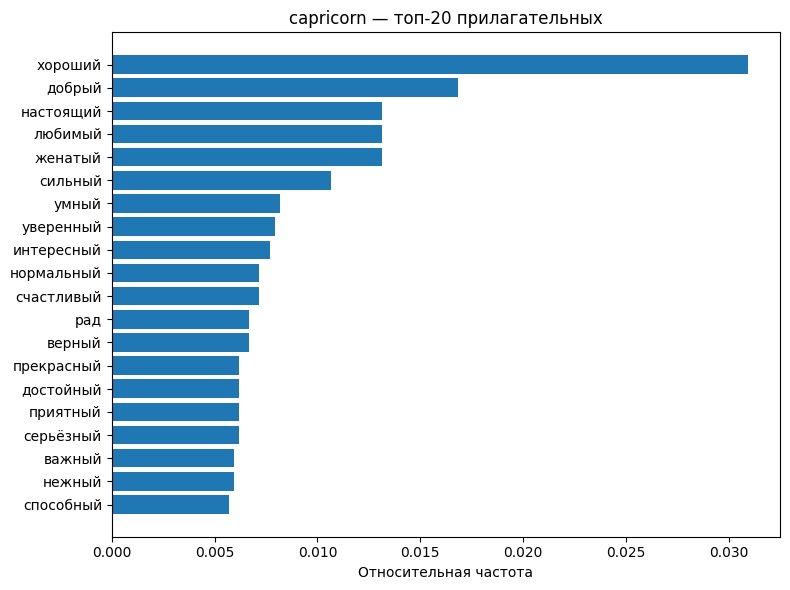

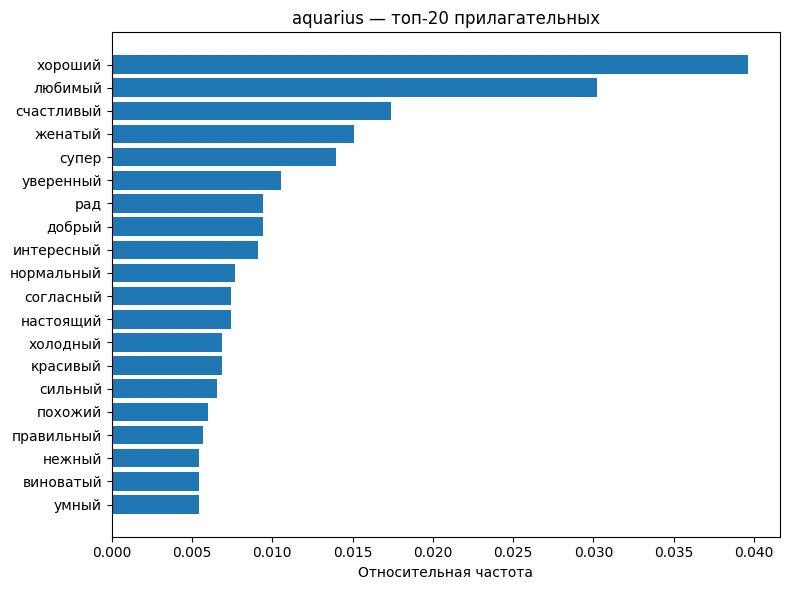

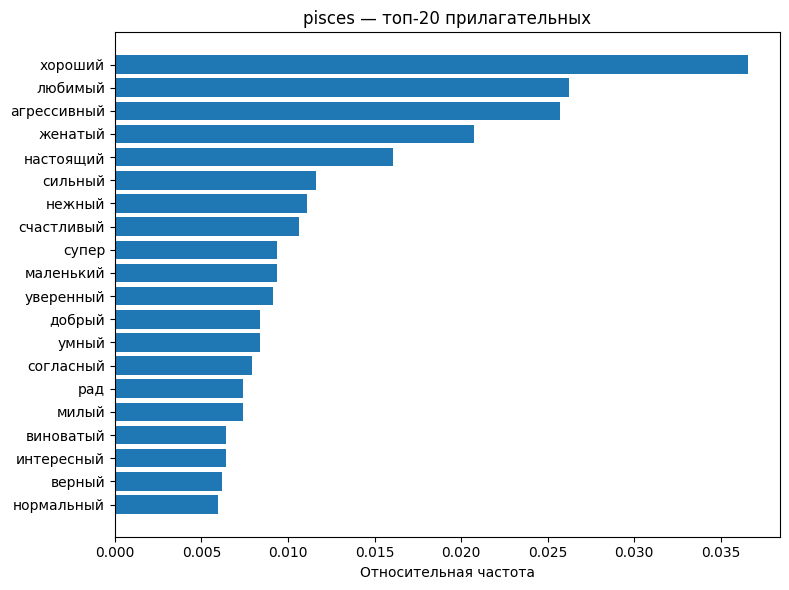

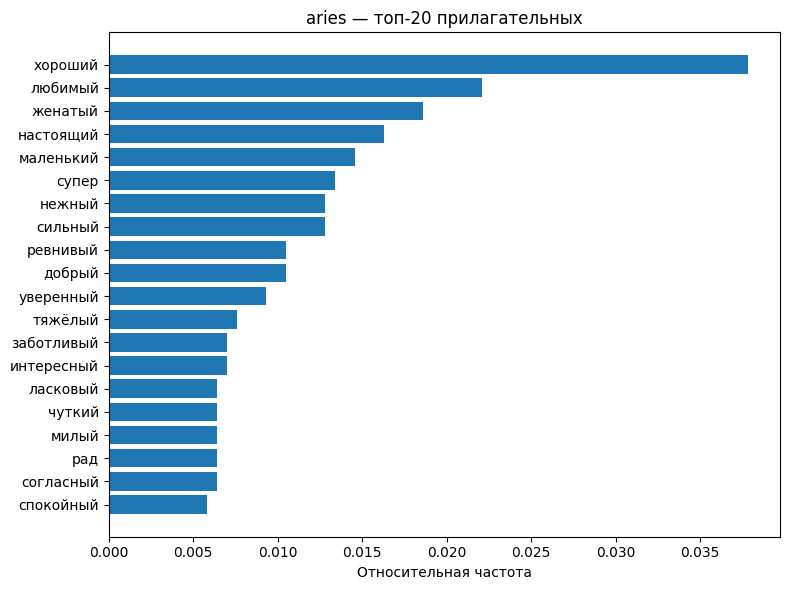

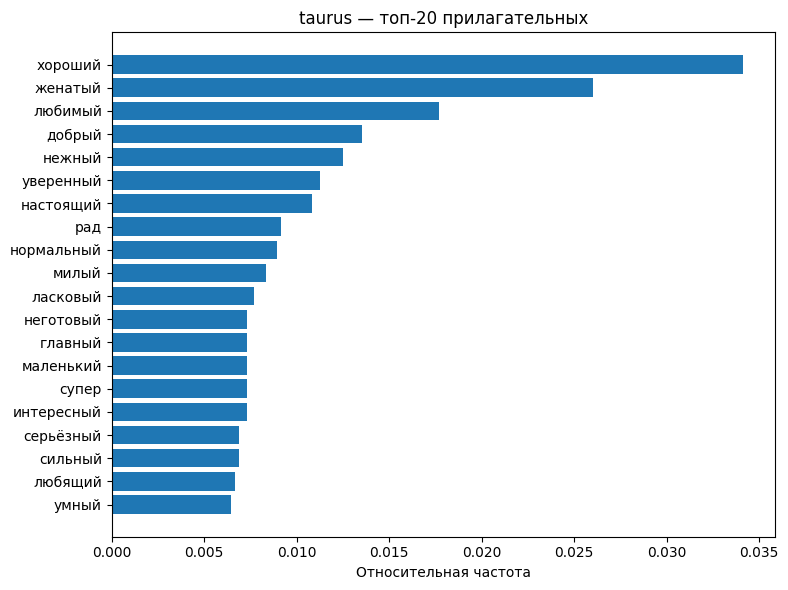

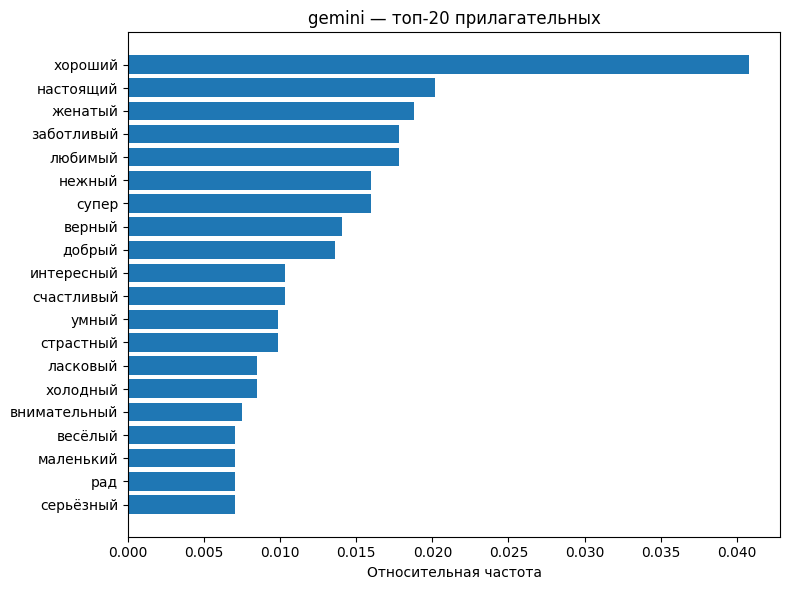

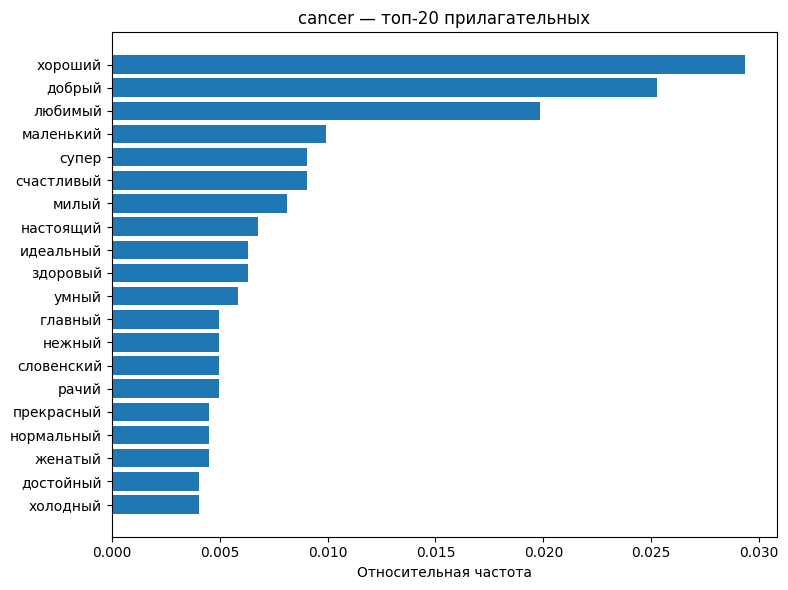

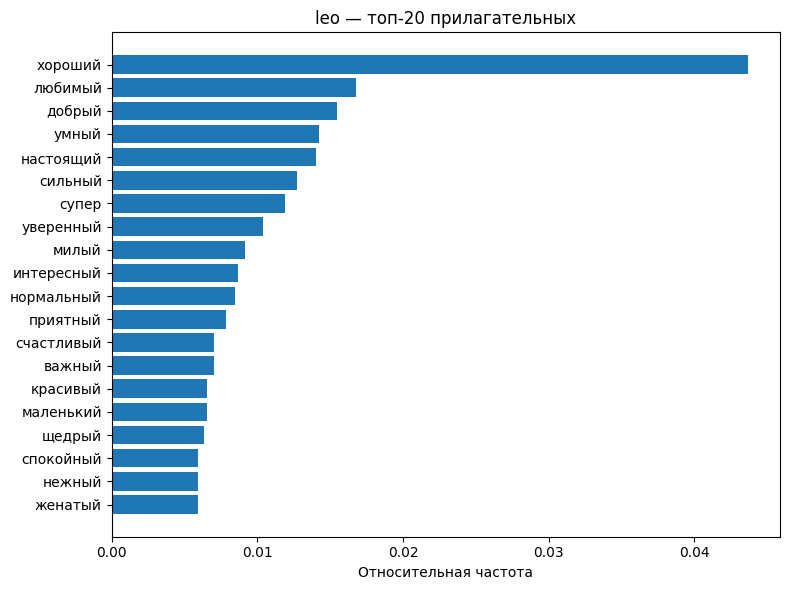

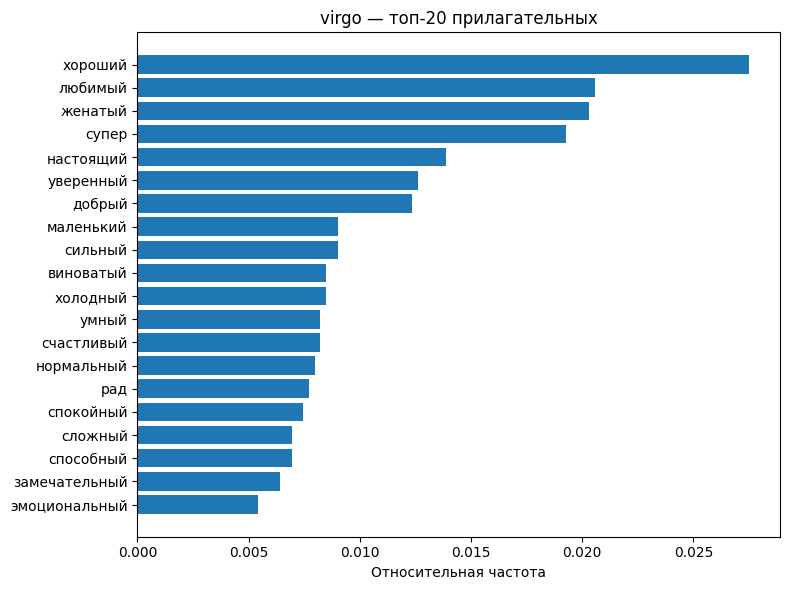

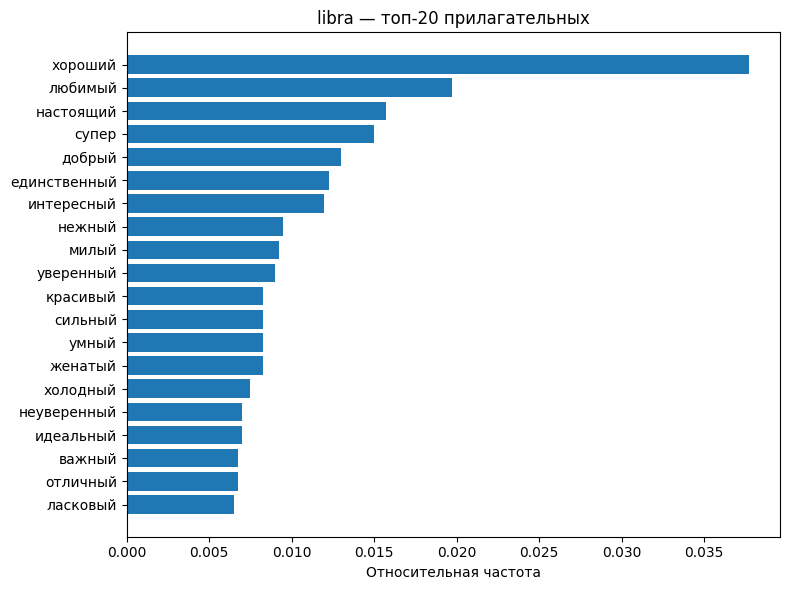

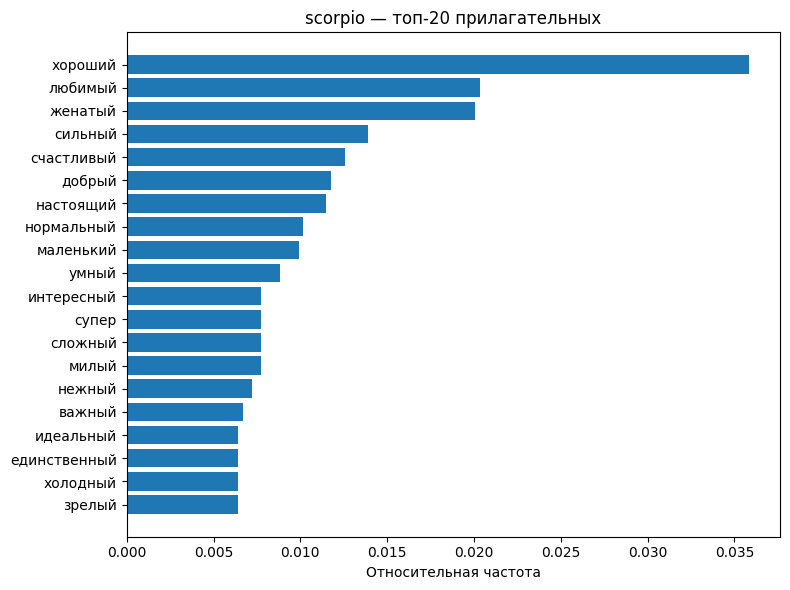

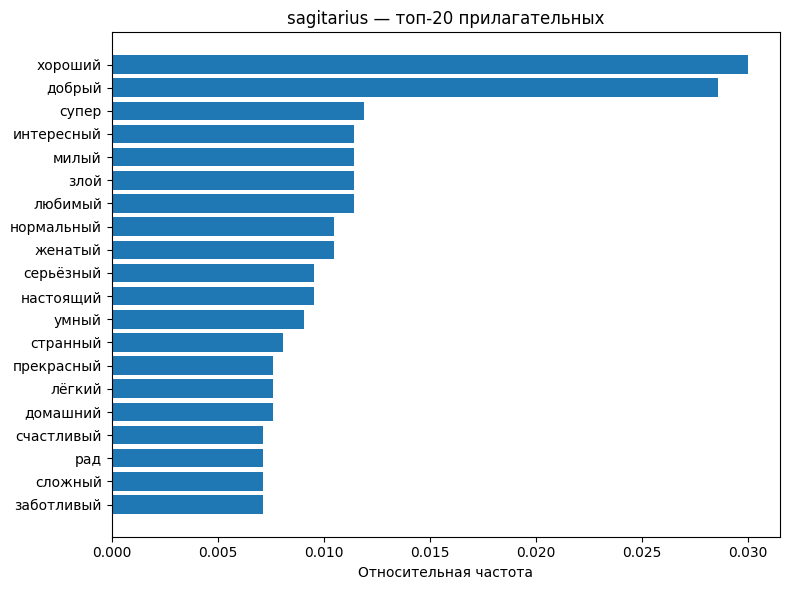

In [39]:
for zodiac, relative_freq in zodiac_adj_rel.items():
    # берем топ-20, отсортированных по убыванию
    top20 = sorted(relative_freq.items(), key=lambda x: x[1], reverse=True)[:20]
    
    words = [word for word, freq in top20]
    freqs = [freq for word, freq in top20]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(words[::-1], freqs[::-1])  # [::-1] чтобы топ-1 был сверху
    
    ax.set_xlabel('Относительная частота')
    ax.set_title(f'{zodiac} — топ-20 прилагательных')
    
    plt.tight_layout()
    plt.savefig(f'{zodiac}_top20.png', dpi=150, bbox_inches='tight')
    plt.show()

## Посчитаем tf-idf для masc_adj (прилагателньые мужского рода)

In [ ]:


signs = list(zodiac_texts.keys()) # лист с названиями знаков из словаря
texts = list(zodiac_texts.values()) # лист с прилагательными-текстами
# настраиваем векторизатор
vectorizer = TfidfVectorizer(
    max_features=20,        # топ-20 слов
    min_df=1,                # минимум в одном знаке
    max_df=0.8,               # игнорируем слова, которые есть в >80% знаков
    ngram_range=(1, 1),       # только отдельные слова
    stop_words=None
)

# считаем TF-IDF
tfidf_matrix = vectorizer.fit_transform(texts)

# получаем названия слов
feature_names = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=signs,
    columns=feature_names
)


display(tfidf_df)


# посмотрим топ-слова для рака

print(tfidf_df.loc['cancer'].sort_values(ascending=False).head(10))

,ведомый,властный,галантный,загадочный,импульсивный,мерзкий,молчаливый,мутный,независимый,незрелый,непредсказуемый,отзывчивый,принципиальный,свободолюбивый,смелый,состоятельный,стеснительный,творческий,терпеливый,целеустремлённый
capricorn,0.000000,0.053462,0.106924,0.000000,0.267310,0.173772,0.405469,0.057924,0.160386,0.000000,0.106924,0.000000,0.377474,0.000000,0.000000,0.479973,0.188737,0.115848,0.481159,0.160386
aquarius,0.038247,0.000000,0.000000,0.165756,0.038247,0.082878,0.041439,0.000000,0.497209,0.041439,0.152987,0.344222,0.135023,0.191234,0.688443,0.000000,0.090015,0.165756,0.076494,0.000000
pisces,0.159029,0.106020,0.053010,0.631775,0.053010,0.057434,0.344605,0.402039,0.318059,0.057434,0.159029,0.106020,0.124760,0.106020,0.106020,0.000000,0.187140,0.114868,0.212039,0.053010
aries,0.000000,0.000000,0.000000,0.311667,0.287658,0.103889,0.000000,0.103889,0.000000,0.207778,0.479431,0.479431,0.451342,0.000000,0.095886,0.000000,0.000000,0.000000,0.287658,0.000000
taurus,0.091677,0.183355,0.137516,0.099329,0.000000,0.000000,0.099329,0.248322,0.183355,0.000000,0.137516,0.366709,0.000000,0.137516,0.137516,0.352741,0.269707,0.248322,0.595903,0.137516
gemini,0.000000,0.000000,0.189792,0.000000,0.094896,0.000000,0.205632,0.000000,0.000000,0.000000,0.474479,0.189792,0.111670,0.284688,0.000000,0.121708,0.223341,0.411265,0.569375,0.000000
cancer,0.527471,0.527471,0.175824,0.000000,0.175824,0.000000,0.190499,0.000000,0.000000,0.190499,0.000000,0.000000,0.000000,0.000000,0.527471,0.000000,0.000000,0.000000,0.000000,0.175824
leo,0.222521,0.667564,0.166891,0.060273,0.166891,0.361641,0.000000,0.060273,0.333782,0.060273,0.000000,0.111261,0.000000,0.055630,0.166891,0.000000,0.000000,0.301367,0.111261,0.222521
virgo,0.080484,0.080484,0.160968,0.000000,0.160968,0.000000,0.000000,0.000000,0.482905,0.000000,0.000000,0.160968,0.000000,0.080484,0.241452,0.619347,0.284133,0.174403,0.241452,0.241452
libra,0.260131,0.065033,0.390197,0.211382,0.325164,0.281843,0.140921,0.140921,0.390197,0.352303,0.130066,0.130066,0.000000,0.130066,0.260131,0.166815,0.000000,0.281843,0.000000,0.065033


ведомый             0.527471
властный            0.527471
смелый              0.527471
молчаливый          0.190499
незрелый            0.190499
галантный           0.175824
целеустремлённый    0.175824
импульсивный        0.175824
загадочный          0.000000
независимый         0.000000
Name: cancer, dtype: float64


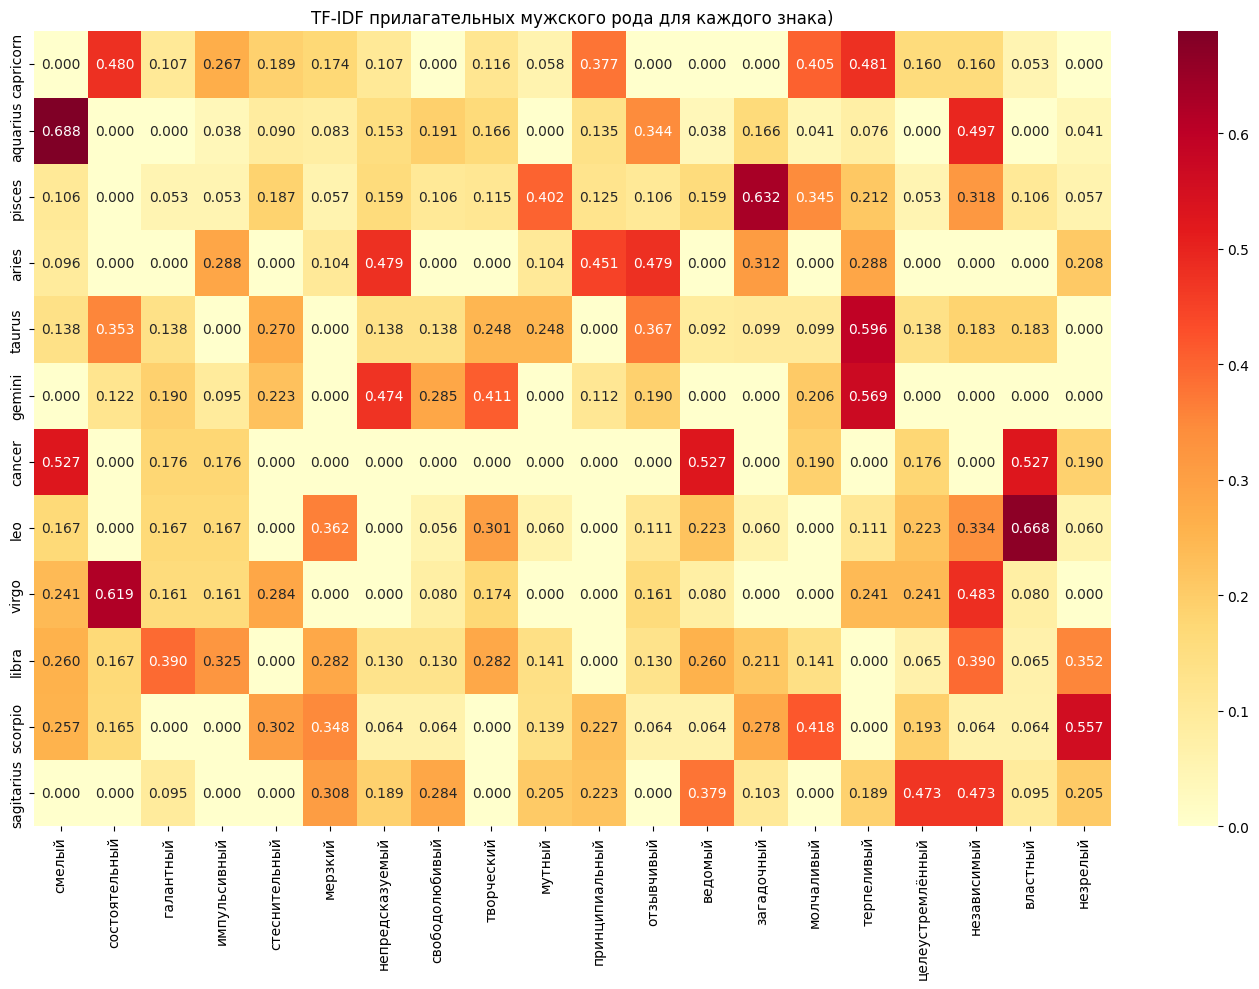

In [ ]:


def plot_tfidf_heatmap(tfidf_df, top_n=10):
    # берем топ-N слов для каждого знака
    top_words = set()
    for sign in tfidf_df.index:
        top_words.update(tfidf_df.loc[sign].nlargest(top_n).index)
    
    # Фильтруем матрицу
    plot_df = tfidf_df[list(top_words)]
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(plot_df, annot=True, fmt='.3f', cmap='YlOrRd',  # annot = TRUE, чтобы значения были с текстом
                xticklabels=True, yticklabels=True)
    plt.title(f'TF-IDF прилагательных мужского рода для каждого знака)')
    plt.tight_layout()
    plt.show()

# строим тепловую карту
plot_tfidf_heatmap(tfidf_df, top_n=10)

## Попробуем посмотреть биграммы и триграммы

In [ ]:

bigram_measures = nltk.collocations.BigramAssocMeasures()


zodiac_texts_for_bigramm = {}
for zodiac, df in zodiac_data_processed.items():
    all_lemmas = []
    for lemmas in df['lemmas'].tolist():
        all_lemmas.extend(lemmas)
    zodiac_texts_for_bigramm[zodiac] = all_lemmas


zodiac_bigrams = {}
for zodiac, documents in zodiac_texts_for_bigramm.items():
    
    bigram_finder = BigramCollocationFinder.from_words(documents, window_size=3)
    
    # фильтруем разделители и стоп-слова
    bigram_finder.apply_word_filter(lambda w: w in set(stop_words) | set(adjective_stop_words))
    bigram_finder.apply_freq_filter(3)

    # считаем PMI
    bigramspmi = bigram_finder.score_ngrams(bigram_measures.pmi)
    
    # оформляем в датафрейм
    bigramspmi_df = pd.DataFrame(
        [[' '.join([b[0][0], b[0][1]]), b[0][0], b[0][1], b[1]] for b in bigramspmi],
        columns=['bigram', 'word_1', 'word_2', 'pmi']
    )
    bigramspmi_df.sort_values(by='pmi', ascending=False, ignore_index=True, inplace=True)
    
    zodiac_bigrams[zodiac] = bigramspmi_df

    # посмотреть результат для одного знака
zodiac_bigrams['aries'].head(20)

,bigram,word_1,word_2,pmi
0,миля муй,миля,муй,13.721153
1,стрессовый некомфортно,стрессовый,некомфортно,13.721153
2,тихня плакальщик,тихня,плакальщик,13.721153
3,тихня мсительный,тихня,мсительный,13.721153
4,стабильность стабильность,стабильность,стабильность,13.721153
5,позабыть раскаиваться,позабыть,раскаиваться,13.721153
6,поразбивать фотоаппарат,поразбивать,фотоаппарат,13.721153
7,пыл охладить,пыл,охладить,13.721153
8,переселиться галактика,переселиться,галактика,13.721153
9,обыденно ненеразвидный,обыденно,ненеразвидный,13.721153


### так как zodiac у нас записаны латиницей сделаем транслейт. мы делаем это, чтобы искать в каждом дф искалась информация по целевому знаку. 
### Далее следует попытка отфильтровать биграммы так, чтобы знак зодиака был на 1 или 2 позиции

In [ ]:
# так как zodiac у нас записаны латиницей сделаем транслейт. мы делаем это, чтобы искать в каждом дф искалась информация по целевому знаку
zodiac_translation = {
    'aries': 'овен',
    'taurus': 'телец',
    'gemini': 'близнецы',
    'cancer': 'рак',
    'leo': 'лев',
    'virgo': 'дева',
    'libra': 'весы',
    'scorpio': 'скорпион',
    'sagitarius': 'стрелец',
    'capricorn': 'козерог',
    'aquarius': 'водолей',
    'pisces': 'рыбы'
}
# попытка отфильтровать биграммы так, чтобы знак зодиака был на 1 или 2 позиции
for zodiac, df in zodiac_bigrams.items():
    zodiac_lemma = zodiac_translation[zodiac]
    zodiac_mentions = df[(df['word_1'] == zodiac_lemma) | (df['word_2'] == zodiac_lemma)]
    print(f'\n=== {zodiac} ===')
    print(zodiac_mentions.head(10))


=== capricorn ===
                     bigram    word_1         word_2       pmi
1331        козерог шикарно   козерог        шикарно  6.186406
1467   козерог честолюбивый   козерог   честолюбивый  5.864478
1504       жлобство козерог  жлобство        козерог  5.771369
1505   козерог благородство   козерог   благородство  5.771369
1506  козерог оптимистичный   козерог  оптимистичный  5.771369
1628       звериный козерог  звериный        козерог  5.508334
1659           юный козерог      юный        козерог  5.449441
1691     козерог похотливый   козерог     похотливый  5.379051
1801           хара козерог      хара        козерог  5.186406
2171            миф козерог       миф        козерог  4.601444

=== aquarius ===
                    bigram        word_1     word_2       pmi
1140          клан водолей          клан    водолей  5.519046
1255        знаток водолей        знаток    водолей  5.256012
1533       водолей творить       водолей    творить  4.711691
1640    нетипичный вод

## Cпособ учитывать части речи в биграммах более результативен

In [ ]:

lemma_to_pos = {}
for zodiac, df in zodiac_data_processed.items():
    for lemmas, poses in zip(df['lemmas'], df['pos']):
        for lemma, pos in zip(lemmas, poses):
            lemma_to_pos[lemma] = pos

# добавляем pos для word_1 и word_2 в биграммный датафрейм
for zodiac, df in zodiac_bigrams.items():
    df['pos_1'] = df['word_1'].map(lemma_to_pos)
    df['pos_2'] = df['word_2'].map(lemma_to_pos)
    zodiac_bigrams[zodiac] = df

# ищем биграммы: знак зодиака + прилагательное
for zodiac, df in zodiac_bigrams.items():
    zodiac_lemma = zodiac_translation[zodiac]
    mask_1 = (df['word_1'] == zodiac_lemma) & (df['pos_2'].isin(['ADJF', 'ADJS']))
    mask_2 = (df['pos_1'].isin(['ADJF', 'ADJS'])) & (df['word_2'] == zodiac_lemma)
    result = df[mask_1 | mask_2]
    
    if len(result) > 0:
        print(f'\n=== {zodiac} ===')
        print(result.head(15))
    else:
        print(f'\n=== {zodiac} === нет результатов')


=== capricorn ===
                    bigram      word_1        word_2       pmi pos_1 pos_2
1467  козерог честолюбивый     козерог  честолюбивый  5.864478  NOUN  ADJS
1628      звериный козерог    звериный       козерог  5.508334  ADJF  NOUN
1659          юный козерог        юный       козерог  5.449441  ADJF  NOUN
1691    козерог похотливый     козерог    похотливый  5.379051  NOUN  ADJF
2172        унылый козерог      унылый       козерог  4.601444  ADJF  NOUN
2173    нетипичный козерог  нетипичный       козерог  4.601444  ADJF  NOUN
2283      козерог скрытный     козерог      скрытный  4.449441  NOUN  ADJF
3062      типичный козерог    типичный       козерог  3.554138  ADJF  NOUN
3092   козерог расчётливый     козерог   расчётливый  3.523441  NOUN  ADJF
3161      присущий козерог    присущий       козерог  3.449441  ADJS  NOUN
3469     козерог непростой     козерог     непростой  3.186406  NOUN  ADJF
3978      козерог надёжный     козерог      надёжный  2.794089  NOUN  ADJF
4077  

##  Попытка найти конструкции типа "козерог-зануда", "скорпион-собственник", "дева-однолюб", что собственно удалось (но также отловилось много мусора)
### здесь уже задача отловить "целевой знак + любое существительное, кроме какого-либо знака"
### поэтому нам нужен список со знаками

In [ ]:

zodiac_names = ['весы', 'лев', 'дева', 'телец', 'овен', 'рак', 'скорпион', 'стрелец', 'козерог', 'водолей', 'рыба', 'близнец']
# добавим еще стоп-слов  неинформативных существительных
noun_stop_words = [
    'январь', 'февраль', 'март', 'апрель', 'май', 'июнь',
    'июль', 'август', 'сентябрь', 'октябрь', 'ноябрь', 'декабрь',
    'мужчина', 'девушка', 'женщина', 'декада', 'девочка', 'мальчик', 'брат'
] 
for zodiac, df in zodiac_bigrams.items():
    zodiac_lemma = zodiac_translation[zodiac]
    # знак + существительное 
    mask_1 = (
        (df['word_1'] == zodiac_lemma) &
        (df['pos_2'] == 'NOUN') &
        (~df['word_2'].isin(zodiac_names)) &
        (~df['word_2'].isin(noun_stop_words))
    )
    result = df[mask_1]
    
    if len(result) > 0:
        print(f'\n=== {zodiac} ===')
        print(result.head(15))
    else:
        print(f'\n=== {zodiac} === нет результатов')


=== capricorn ===
                    bigram   word_1        word_2       pmi pos_1 pos_2
1505  козерог благородство  козерог  благородство  5.771369  NOUN  NOUN
2691        козерог ракиня  козерог        ракиня  3.964014  NOUN  NOUN
3240        козерог зануда  козерог        зануда  3.379051  NOUN  NOUN
3718    козерог исключение  козерог    исключение  2.976953  NOUN  NOUN
3741      козерог гибкость  козерог      гибкость  2.964014  NOUN  NOUN
3751        козерог львица  козерог        львица  2.949367  NOUN  NOUN
5148           козерог год  козерог           год  2.076973  NOUN  NOUN
6693            козерог ум  козерог            ум  1.396329  NOUN  NOUN
7067      козерог гороскоп  козерог      гороскоп  1.255669  NOUN  NOUN
7251    козерог знакомство  козерог    знакомство  1.186406  NOUN  NOUN
7311           козерог тип  козерог           тип  1.171456  NOUN  NOUN
7332       козерог неочень  козерог       неочень  1.164038  NOUN  NOUN
7384          козерог брак  козерог          

## Попытка отловить конструкции-описания "жесткий, бескомпромиссный, властный"

In [ ]:

for zodiac, df in zodiac_bigrams.items():
    mask_3 = (df['pos_1'] == 'ADJF') & (df['pos_2'] == 'ADJF')
    result = df[mask_3]
    print(f'=== {zodiac} ===')
    print(result.head(15))

=== capricorn ===
                           bigram        word_1           word_2        pmi  \
113           похотливый занудный    похотливый         занудный  12.445141   
131      позитивный созидательный    позитивный    созидательный  12.252495   
137           похотливый мелочный    похотливый         мелочный  12.182106   
163                 глухой слепой        глухой           слепой  11.793064   
170             мелочный занудный      мелочный         занудный  11.667533   
186                 земной водный        земной           водный  11.486961   
204                 слепой глухой        слепой           глухой  11.378026   
211   романтичный сентиментальный   романтичный  сентиментальный  11.252495   
287                тихий скромный         тихий         скромный  10.452027   
333            способный исходный     способный         исходный  10.165033   
364          шаблонный правильный     шаблонный       правильный   9.989461   
394     единственный неповторимый 

## Здесь мы настраиваем поиск-триграмм и сначала получаем бред. Потом будем снова фильтровать по pos

In [ ]:


# здесь мы настраиваем поиск-триграмм и сначала получаем бред

zodiac_trigrams = {}
for zodiac, documents in zodiac_texts_for_bigramm.items(): # используем тот же словарь, куда клали леммы
    trigram_finder = TrigramCollocationFinder.from_words(documents)
    # фильтруем 
    trigram_finder.apply_word_filter(lambda w: w in set(stop_words) | set(adjective_stop_words))
    trigram_finder.apply_freq_filter(2)

    # считаем PMI
    trigramspmi = trigram_finder.score_ngrams(TrigramAssocMeasures.pmi)
    
    # оформляем в датафрейм
    trigramspmi_df = pd.DataFrame(
        [[' '.join([t[0][0], t[0][1], t[0][2]]), t[0][0], t[0][1], t[0][2], t[1]] for t in trigramspmi],
        columns=['trigram', 'word_1', 'word_2', 'word_3', 'pmi']
    )
    trigramspmi_df.sort_values(by='pmi', ascending=False, ignore_index=True, inplace=True)
    
    zodiac_trigrams[zodiac] = trigramspmi_df
for zodiac, df in zodiac_trigrams.items():
    print(f'===={zodiac}====')
    print(df.head(20))


====capricorn====
                                trigram           word_1       word_2  \
0                 завидеть вдали купюра         завидеть        вдали   
1       согнать концлагерь оглянуситься          согнать   концлагерь   
2            ткань акромегалия ожирение            ткань  акромегалия   
3      воспаление гипертрофия набухание       воспаление  гипертрофия   
4           гипертрофия набухание ткань      гипертрофия    набухание   
5       детектив выслеживать вынюхивать         детектив  выслеживать   
6            блондинка смазливый личико        блондинка    смазливый   
7           набухание ткань акромегалия        набухание        ткань   
8      разноимённый заряд притягиваться     разноимённый        заряд   
9   разрастание включая злокачественный      разрастание      включая   
10               вдали купюра вкалывать            вдали       купюра   
11        выслеживать вынюхивать скелет      выслеживать   вынюхивать   
12             склока дрязг перем

In [ ]:
for zodiac, df in zodiac_trigrams.items():
    df['pos_1'] = df['word_1'].map(lemma_to_pos)
    df['pos_2'] = df['word_2'].map(lemma_to_pos)
    df['pos_3'] = df['word_3'].map(lemma_to_pos)
    zodiac_bigrams[zodiac] = df
    mask_4 = df['pos_1'].isin(['ADJF', 'ADJS']) & df['pos_2'].isin(['ADJF', 'ADJS'])
    result = df[mask_4]
    print(f'=== {zodiac} ===')
    print(result.head(10))

=== capricorn ===
                                   trigram         word_1       word_2  \
20   экономический социалный биологический  экономический    социалный   
58               военный учебный заведение        военный      учебный   
94        честолюбивый похотливый мелочный   честолюбивый   похотливый   
104      византийский религиозный традиция   византийский  религиозный   
137        сексуальный популярный везунчик    сексуальный   популярный   
141       сверхценный умственный концепция    сверхценный   умственный   
142          мелочный занудный справедливо       мелочный     занудный   
144           похотливый мелочный занудный     похотливый     мелочный   
157              конфетный букетный период      конфетный     букетный   
207             глубокий языковой познание       глубокий     языковой   

            word_3        pmi pos_1 pos_2 pos_3  
20   биологический  30.979173  ADJF  ADJF  ADJF  
58       заведение  29.278734  ADJF  ADJF  NOUN  
94        мелочны

## Теперь возьмем эталонные тексты со стереотипами о знаках, чтобы сравнить с получившимся у нас прежде характеристиками. 


Мужчина-Близнецы ждет от жизни ярких впечатлений, поэтому удержать дома его вряд ли удастся. Он не приемлет однообразие и тишину. И перевоспитать его никому не удастся. Близнецы обожают быть в центре внимания и не пропускают все светские тусовки. Обаятельны от природы, они виртуозно умеют льстить, поэтому быстро находят себе поклонниц. Однако секс на одну ночь они не очень любят, им нужна влюбленность и романтичная обстановка. Если им комфортно, в постели Близнецы будут вести себя страстно и раскрепощенно.
Серьезные отношения построить с представителями этого знака будет непросто. В личной жизни мужчина-Близнецы неисправимый эгоист, поэтому ищет лояльного партнера, готового прощать всего его загулы и выходки. Будьте готовы к тому, что через пару минут после душевного разговора с вами он уже позабудет обо всём и побежит в ближайший бар с друзьями. Ему постоянно надо куда-то двигаться, переключаться с одного дела на другое. Вернется под утро, возможно после сомнительных приключений. Пред

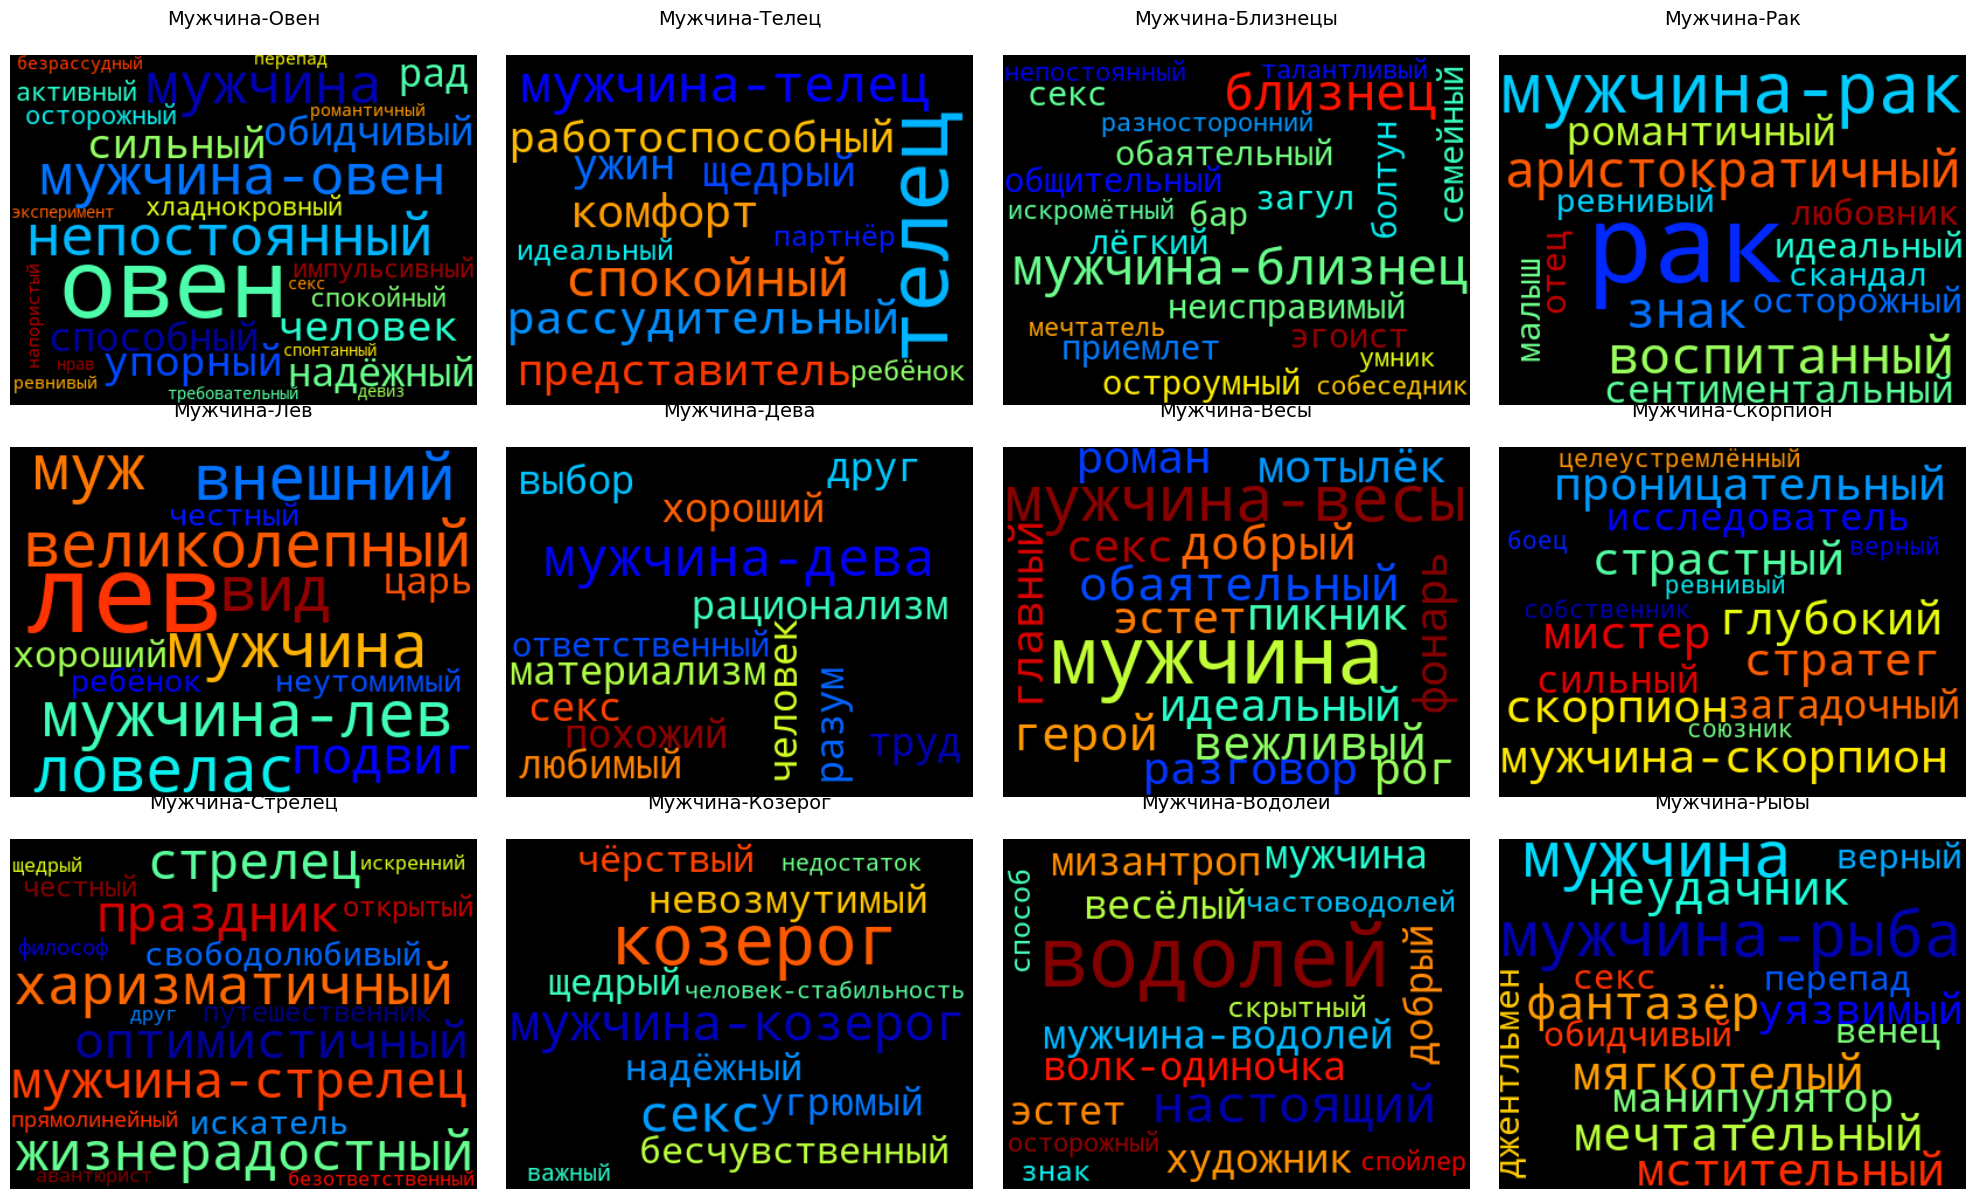

In [ ]:

with open(("stereotypes.txt"), encoding="utf-8") as f: #должно лежать в папке 
    raw = f.read()

parts = re.split(r'Мужчина-[А-ЯЁа-яё]+\n', raw)
parts= parts[1:]
signs = re.findall(r'Мужчина-[А-ЯЁа-яё]+\n', raw)  # для графика
print(parts[2]) # проверили, что записали текст и что с нулевого индекса у нас идет овен 

def extract_adjectives(text):
    words  = word_tokenize(text.lower())
    adjectives = []
    for word in words:
        parsed = morph.parse(word)[0]
        if (parsed.tag.POS in {'ADJF', 'ADJS', 'NOUN'} # если прил или сущ
    and (parsed.tag.gender == 'masc' 
         or (parsed.tag.POS == 'ADJS' and parsed.tag.number == 'plur')) # если м. р или кр. прилагательное мн.ч
    and (parsed.tag.case == 'nomn' # если в им.п. или кр.прил(у них case = None)
         or parsed.tag.POS == 'ADJS')
    and parsed.normal_form not in stop_words
    and parsed.normal_form not in adjective_stop_words):
            adjectives.append(parsed.normal_form)
    return adjectives

cols = 4
rows = -(-len(parts) // cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for idx, text in enumerate(parts):
    adjectives = extract_adjectives(text)
    freq = Counter(adjectives)

    wc = WordCloud(
        width=400, height=300,
        background_color="black",
        colormap="jet",
        max_words=40,
    ).generate_from_frequencies(freq)

    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].axis("off")
    axes[idx].set_title(signs[idx], fontsize=14)

for idx in range(len(parts), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig("zodiac_adjectives.png", dpi=150, bbox_inches="tight")
plt.show()